# Aprendizaje Automático
## Trabajo Práctico 1

Para la realización de los ejercicios, se consideran los datos del archivo Préstamo.csv los
cuales fueron descargados del enlace https://www.kaggle.com/datasets/taweilo/loan-a
pproval-classification-data. Este conjunto de datos contiene información sobre personas
que solicitaron un crédito bancario.


Ejercicio 1.
<br>
Se desea conocer el estado de la solicitud del préstamo (OTORGADO o RECHA-
ZADO) para personas de 50 años conociendo su sexo, su máximo nivel educativo alcanzado, su
estado de vivienda (si posee una propiedad propia, posee una hipoteca o alquila) y sabiendo si
posee préstamos previos impagos.
1. Considerar los primeros ejemplos que cubren el 75 % del total de ejemplos como conjunto
de entrenamiento y el resto como conjunto de prueba.
2. Implementar el algoritmo FIND-S.
3. Aplicar la hipótesis obtenida para predecir el estado de la solicitud del préstamo en el
conjunto de prueba.

In [ ]:
import pandas as pd


df = pd.read_csv('prestamo.csv', encoding='latin-1')

# Filtrar por 50 años
df_50 = df[df['Edad'] == 50].copy()

columnas = ['Sexo', 'Mayor nivel educativo', 'Estado de vivienda', 'Préstamos previos impagos']
estado = 'Estado'

# Dividir en Entrenamiento (75%) y Prueba (25%)
limite  = int(len(df_50) * 0.75)
entrenamiento = df_50.iloc[:limite]
prueba = df_50.iloc[limite:]


# Algoritmo FIND-S
def find_s(data, atributos, concepto):
    h = ['0'] * len(atributos)
    positivos = data[data[concepto] == 'OTORGADO']
    for j, fila in positivos.iterrows():
        for i, col in enumerate(atributos):
            valor_actual = str(fila[col])
            if h[i] == '0':
                h[i] = valor_actual
            elif h[i] != valor_actual:
                h[i] = '?'
    return h

hipotesis = find_s(entrenamiento, columnas, estado)
print(f"Hipótesis obtenida: {hipotesis}")


# Algoritmo de predicción
def predecir(hipotesis, registro, atributos):
    for i, valor in enumerate(hipotesis):
        if valor != '?' and valor != registro[atributos[i]]:
            return 'RECHAZADO'
    return 'OTORGADO'


# Predicción en el conjunto de prueba
aciertos = 0
no_aciertos = 0
for i, registro in prueba.iterrows():
    prediccion = predecir(hipotesis, registro, columnas)
    es_correcto = prediccion == registro[estado]
    if es_correcto:
        aciertos += 1
    else:
        no_aciertos += 1


    print(f"Real: {registro[estado]} | Predicción: {prediccion} | {'OK' if es_correcto else 'ERROR'}")
print(aciertos)
print(no_aciertos)


Ejercicio 2.
<br>
A partir de los resultados obtenidos en el Ejercicio 1., se pide lo siguiente.
1. Calcula la matriz de confusión.
2. Calcular el accuracy, el recall, la especificidad y la precisión.
3. Calcular el F1-score.
4. Calcular la tasa de verdaderos positivos y la tasa de falsos positivos.

In [ ]:
##########  Métricas  ##########

# Calculamos los 4 valores posibles de los datos: True Positive (TP), False Positive (FP), True Negative (TN), False Negative (FN)
# para un vector de predicciones y uno de esperados. OTORGADO == Positive, RECHAZADO == Negative
def calcularPositivosYnegativos(predicciones, esperados):
  TP = 0
  FP = 0
  TN = 0
  FN = 0
  # Recorremos el vector de predicciones y comparamos el resultado con el esperado
  for i in range(len(predicciones)):
      if predicciones[i] == 'OTORGADO':   # Predicciones POSITVAS
        if esperados[i] == 'OTORGADO':
          TP += 1
        else:
          FP += 1
      else:                               # Predicciones NEGATIVAS
        if esperados[i] == 'RECHAZADO':
          TN += 1
        else:
          FN += 1
  return TP,FP,TN,FN

# Creamos los conjuntos de predicciones y de esperados
conj_predicciones = []
conj_esperados = []

for i, registro in prueba.iterrows():
   conj_predicciones.append(predecir(hipotesis, registro, columnas))
   conj_esperados.append(registro[estado])

# Calculamos sus variables
TP, FP, TN, FN = calcularPositivosYnegativos(conj_predicciones, conj_esperados)

# Matriz de confusión para un conjunto de predicciones y esperados
def matrizDeConfusion(predicciones, esperados):
  tp, fp, tn, fn = calcularPositivosYnegativos(predicciones, esperados)
  return [[tp, fn], [fp, tn]]

def accuracy(tp, fp, tn, fn):
  return (tp + tn) / (tp + tn + fp + fn)

def recall(tp, fn):
  return tp / (tp + fn)

def especificidad(fp, tn):
  return tn / (tn + fp)

def precision(tp, fp):
  return tp / (tp + fp)

def f1_score(tp, fp, fn):
  return 2 * (precision(tp, fp) * recall(tp, fn)) / (precision(tp, fp) + recall(tp, fn))

def tpr_fpr(tp, fp, tn, fn):
  return tp / (tp + fn), fp / (tn + fp)

print(f"Matriz de confusión:")
matriz = matrizDeConfusion(conj_predicciones, conj_esperados)
print(matriz[0])
print(matriz[1])
print(f"Accuracy: {accuracy(TP,FP,TN,FN)}")
print(f"Recall: {recall(TP,FN)}")
print(f"Especificidad: {especificidad(FP,TN)}")
print(f"Precisión: {precision(TP,FP)}")
print(f"F1-score: {f1_score(TP,FP,FN)}")
print(f"TPR, FPR: {tpr_fpr(TP,FP,TN,FN)}")

Ejercicio 3.
<br>
Se desea conocer el estado de la solicitud del préstamo (OTORGADO o RECHA-
ZADO) para personas de entre 40 y 45 años a partir de los atributos categóricos.
1. Dividir aleatoriamente el conjunto de datos para utilizar una parte de los mismos como
conjunto de entrenamiento (el 80 %) y otro como conjunto de prueba (el 20 %).
2. Utilizar el clasificador naı̈ve de Bayes para clasificar los ejemplos del conjunto de prueba.
3. Construir la matriz de confusión para el conjunto de prueba.
4. Calcular el accuracy y el F1-score.
5. Graficar la curva ROC para el conjunto de prueba.


Clase: OTORGADO

Matriz de confusión:
                Pred OTORGADO   Pred RECHAZADO
Real OTORGADO      TP=33          FN=30
Real RECHAZADO    FP=40          TN=183

Accuracy  : 0.7552
Precisión : 0.4521
Recall    : 0.5238
F1-score  : 0.4853

AUC = 0.7996


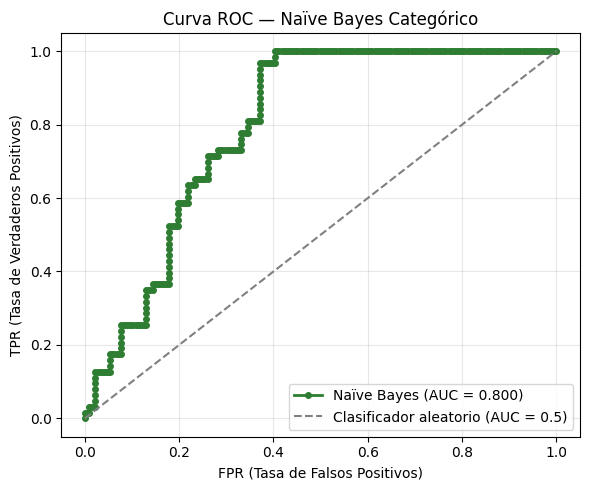

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('prestamo.csv', encoding='latin-1')

# Filtrar por edad entre 40 y 45
df_filtrado = df[(df['Edad'] >= 40) & (df['Edad'] <= 45)].copy()

columnas = ['Sexo', 'Mayor nivel educativo', 'Estado de vivienda', 'Préstamos previos impagos']
estado = 'Estado'

# Dividir en Entrenamiento (80%) y Prueba (20%)
limite  = int(len(df_filtrado) * 0.80) # saco la cantidad de el %80 de la cantidad de registros
entrenamiento = df_filtrado.iloc[:limite] # tomo los primeros registros para entrenamiento
prueba = df_filtrado.iloc[limite:]  # y los demas hasta el final para prueba

clases = entrenamiento[estado].unique()
N = len(entrenamiento) # total de ejemplos
d = len(columnas) # cantidad de atributos
l = 1  # suavizado de Laplace
K = len(clases)  # cantidad de clases

# probabilidades de cada clase
pi = {}
for c in clases:
    # π_k = (#{Y = Ck} + l) / (N + l*K)
    pi[c] = (len(entrenamiento[entrenamiento[estado] == c]) + l) / (N + l * K)

# cantidad de posibles valores de cada atributo
x = {}  # x[atributo][valor][clase]

for col in columnas:
    x[col] = {}
    valores_posibles = entrenamiento[col].unique()  # Mj valores que puede tomar cada atributo
    Mj = len(valores_posibles)

    for val in valores_posibles:
        x[col][val] = {}
        for c in clases:
            filas_clase = entrenamiento[entrenamiento[estado] == c]
            num   = len(filas_clase[filas_clase[col] == val]) + l
            denom = len(filas_clase) + l * Mj
            x[col][val][c] = num / denom

def calculoBayes(fila, pi, x, clases, columnas):
    scores = {}
    for c in clases:
        score = pi[c]
        for col in columnas:
            val = fila[col]
            score *= x[col][val][c]
        scores[c] = score
    return max(scores, key=scores.get), scores

y_pred  = []
y_prob  = []
y_real  = []

clase_rech = clases[0]
clase_otorg = clases[1]

for _, fila in prueba.iterrows():
    pred, scores = calculoBayes(fila, pi, x, clases, columnas)
    y_pred.append(pred)
    y_real.append(fila[estado])

    # P1 / (P1 + P2)
    total = sum(scores.values())
    y_prob.append(scores[clase_otorg] / total if total > 0 else 0)

# Predicciones de cada caso (log)
# for i, (_, fila) in enumerate(prueba.iterrows()):
#     pred, scores = calculoBayes(fila, pi, x, clases, columnas)
#     print(f"Ejemplo {i+1}: Real={fila[estado]} | Pred={pred} | "
#           f"Score OTORGADO={scores['OTORGADO']:.6f} | Score RECHAZADO={scores['RECHAZADO']:.6f}")

TP, FP, TN, FN = calcularPositivosYnegativos(y_pred, y_real)

print(f"\nClase: {clase_otorg}")
print(f"\nMatriz de confusión:")
print(f"                Pred {clase_otorg}   Pred {clase_rech}")
print(f"Real {clase_otorg}      TP={TP}          FN={FN}")
print(f"Real {clase_rech}    FP={FP}          TN={TN}")


print(f"\nAccuracy  : {accuracy(TP,FP,TN,FN):.4f}")
print(f"Precisión : {precision(TP,FP):.4f}")
print(f"Recall    : {recall(TP,FN):.4f}")
print(f"F1-score  : {f1_score(TP,FP,FN):.4f}")

# GRAFICO Curva ROC
# score y clase real en una lista de pares ordenados
pares = sorted(zip(y_prob, y_real), reverse=True)

total_pos = TP + FN   # P = total positivos reales
total_neg = FP + TN   # N = total negativos reales

puntos_fpr = [0]
puntos_tpr = [0]

tp = 0
fp = 0

for score, real in pares:
    if real == clase_otorg:
        tp += 1   # era positivo y ahora lo clasificamos como positivo → VP
    else:
        fp += 1   # era negativo pero lo clasificamos como positivo → FP
    tpr = tp / total_pos   # TPR = VP / P
    fpr = fp / total_neg   # FPR = FP / N
    puntos_tpr.append(tpr)
    puntos_fpr.append(fpr)

auc_val = 0
for i in range(len(puntos_fpr) - 1):
    base   = puntos_fpr[i+1] - puntos_fpr[i]        # ancho del trapecio
    altura = (puntos_tpr[i+1] + puntos_tpr[i]) / 2  # altura promedio
    auc_val += base * altura

print(f"\nAUC = {auc_val:.4f}")

plt.figure(figsize=(6, 5))

# curva ROC del modelo
plt.plot(puntos_fpr, puntos_tpr, color='#2E7D32', lw=2,
         marker='o', markersize=4, label=f'Naïve Bayes (AUC = {auc_val:.3f})')

# Línea del clasificador aleatorio (TPR = FPR)
plt.plot([0, 1], [0, 1], color='gray', lw=1.5,
         linestyle='--', label='Clasificador aleatorio (AUC = 0.5)')

plt.xlabel("FPR (Tasa de Falsos Positivos)")
plt.ylabel("TPR (Tasa de Verdaderos Positivos)")
plt.title("Curva ROC — Naïve Bayes Categórico")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()